In [1]:
import os
import importlib
import sys

# 添加 parent_folder 到 sys.path
sys.path.append(os.path.abspath("../"))

import train_utils

importlib.reload(train_utils)  # 重新加载模块
os.chdir("c:\\Users\\HANJ29\\Applications\\deepstock\\")

from train_utils import (
    load_train_test_dataset,
    train_model,
    save_model,
    print_fit_report,
    draw_learning_curve,
    print_label_distribution,
    feature_importance,
    save_training_results, plot_histograms
)


FREQ = "D"
VERSION = "0.2"
MODEL_NAME = "RF"
labels = [
    "top_or_bottom",
    "top_or_bottom_stat",
    "top_bottom_volatility_stat",
    "top_or_bottom_optimized",
    "top_or_bottom_stat_optimized",
    "top_bottom_volatility_optimized",
]
features = [
    "change",
    "pct_chg",
    "vol",  # 0.02
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",  # 0.02
    # "dea",  # 0.02
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    # "pe",
    # "pe_ttm", 当为负值时得到的数据为NaN
    "pb",
    "ps",  # 0.02
    "ps_ttm",  # 0.02
    "dv_ratio",  # 0.02
    "dv_ttm",  # 0.02
    "total_share",  # 0.02
    "float_share",  # 0.02
    "free_share",
    "total_mv",  # 0.02
    "circ_mv",  # 0.02
    "float_share_ratio",  # 0.02
    "free_share_ratio",  # 0.02
    "mab_10",
    "mab_25",
    "mab_60",
    "mab_120",
    "mab_200",
]

c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd

# X_train = pd.read_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_dataset_D_0.1.csv")
# X_test = pd.read_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/test_dataset_D_0.1.csv")

In [17]:
VERSION = "0.2"
X_train, X_test, y_train, y_test = load_train_test_dataset(
    freq=FREQ,
    version=VERSION,
    features=features,
)

Train dataset loaded from C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training\train_dataset_D_0.2.csv
Test dataset loaded from C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training\test_dataset_D_0.2.csv
split train data to X and y
X_train shape: (7924061, 36), y_train shape: 6
split test data to X and y
X_test shape: (3528572, 36), y_test shape: 6


In [4]:
X_train.columns

Index(['change', 'pct_chg', 'vol', 'atr', 'pct_vol_chg', 'pct_o2c',
       'lower_shadow', 'upper_shadow', 'dif', 'bar', 'rsi_6', 'rsi_12',
       'rsi_24', 'k', 'd', 'j', 'turnover_rate', 'turnover_rate_f',
       'volume_ratio', 'pb', 'ps', 'ps_ttm', 'dv_ratio', 'dv_ttm',
       'total_share', 'float_share', 'free_share', 'total_mv', 'circ_mv',
       'float_share_ratio', 'free_share_ratio', 'mab_10', 'mab_25', 'mab_60',
       'mab_120', 'mab_200'],
      dtype='object')

In [3]:
y_train["top_or_bottom_optimized"].value_counts()

top_or_bottom_optimized
0    5201632
2    1363835
1    1358594
Name: count, dtype: int64

模型code
- LR - logistic regression
- RF - random forest
- SVM - support vector machine
- ANN - artificial neural network
- DT - decision tree
- GBM - gradient boosting machine
- XGB - extreme gradient boosting
- LGB - light gradient boosting
- CAT - catboost


In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 获取每个类别的数量
COUNT_PER_CLASS = 100000 # 每个类别的样本数量
class_counts = y_train['top_or_bottom_optimized'].value_counts()
print("原始类别分布:")
print(class_counts)


原始类别分布:
top_or_bottom_optimized
0    5201632
2    1363835
1    1358594
Name: count, dtype: int64


In [121]:
y_test['top_or_bottom_optimized'].value_counts()

top_or_bottom_optimized
0    2351820
1     589474
2     587278
Name: count, dtype: int64

In [26]:
# 确定少数类的数量
minority_class_counts = class_counts.min()


In [ ]:

# sampling_strategy = {0: minority_class_counts}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
sampling_strategy = {0: COUNT_PER_CLASS * 20, 1: int(COUNT_PER_CLASS * 5), 2: int(COUNT_PER_CLASS * 5)}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train["top_or_bottom_optimized"])
y_resampled.value_counts()

In [27]:
from imblearn.over_sampling import SMOTE

sampling_strategy = {1: minority_class_counts * 2, 2: minority_class_counts * 2}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train["top_or_bottom_optimized"])

c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [31]:
y_resampled.value_counts()

top_or_bottom_optimized
0    5201632
2    2717188
1    2717188
Name: count, dtype: int64

In [29]:
X_resampled.to_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_dataset_D_0.2(1,2by2).csv", index=False)
y_resampled.to_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_labels_D_0.2(1,2by2).csv", index=False)

In [5]:
X_resampled = pd.read_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_dataset_D_0.2_resampled(1,2by2).csv")
print("train dataset loaded")
y_resampled = pd.read_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_labels_D_0.2_resampled(1,2by2).csv")
print("train labels loaded")

train dataset loaded
train labels loaded


In [ ]:
# 训练模型
# Current label distribution:
# top_or_bottom_optimized
# 0    268571
# 2     72591
# 1     72369
def get_hyper_param(param_name):

    # 定义超参数字典
    RF = {
        'n_estimators': 1000,#500, #100,          # 初始树的数量，适中即可，后续可增加
        'max_depth': None,#15,#None,            # 不限制树的深度，观察模型是否过拟合
        'min_samples_split': 10,#20,#10,      # 内部节点再分裂所需的最小样本数
        'min_samples_leaf': 5,#10,#5,        # 叶子节点的最小样本数，防止过拟合
        'max_features': 'sqrt',       # 每次分裂时考虑的最大特征数，sqrt 是推荐值
        'class_weight': {0:1,1:3,2:3},#{0:1,1:4,2:4},#'balanced',   # 根据类别样本数量自动调整权重
        'random_state': 42,           # 固定随机种子，保证结果可复现
        'n_jobs': -1                  # 使用所有可用 CPU 核心进行并行计算
    }
    # 定义超参数字典
    XGB = {
        'objective': 'multi:softmax',  # 多分类问题，使用 softmax 输出类别
        'num_class': 3,               # 类别数量（根据实际类别数调整）
        'learning_rate': 0.1,         # 初始学习率，后续可调小（如 0.05 或 0.01）
        'max_depth': 6,               # 树的最大深度，适中即可，防止过拟合
        'min_child_weight': 1,        # 最小叶子节点样本权重和，防止过拟合
        'subsample': 0.8,             # 每棵树使用的样本比例，防止过拟合
        'colsample_bytree': 0.8,      # 每棵树使用的特征比例，防止过拟合
        'gamma': 0,                   # 分裂节点的最小损失减少，初始为 0
        'n_estimators': 100,          # 初始树的数量，后续可增加
        'scale_pos_weight': 1,        # 类别不平衡时调整权重，初始为 1
        'random_state': 42,           # 固定随机种子
        'n_jobs': -1                  # 使用所有 CPU 核心
    }
    # 超参数
    LGBM = {
        'objective': 'multiclass',    # 多分类问题
        'num_class': 3,               # 类别数量（根据实际类别数调整）
        'learning_rate': 0.1,         # 初始学习率
        'max_depth': -1,              # 不限制树的深度，观察是否过拟合
        'num_leaves': 31,             # 每棵树的最大叶子数，控制模型复杂度
        'min_data_in_leaf': 20,       # 每个叶子节点的最小样本数，防止过拟合
        'feature_fraction': 0.8,      # 每棵树使用的特征比例
        'bagging_fraction': 0.8,      # 每棵树使用的样本比例
        'bagging_freq': 5,            # 每 5 次迭代进行一次样本重采样
        'lambda_l1': 0.0,             # L1 正则化
        'lambda_l2': 0.0,             # L2 正则化
        'n_estimators': 100,          # 初始树的数量
        'random_state': 42,           # 固定随机种子
        'n_jobs': -1                  # 使用所有 CPU 核心
    }
    # 定义超参数字典
    CAT = {
        'loss_function': 'MultiClass',  # 多分类问题
        'learning_rate': 0.1,          # 初始学习率
        'depth': 6,                    # 树的深度，控制模型复杂度
        'iterations': 1000,            # 最大迭代次数（树的数量）
        'l2_leaf_reg': 3,              # L2 正则化系数，防止过拟合
        'border_count': 32,            # 特征分箱的边界数量，默认 32
        'random_strength': 1,          # 控制分裂时的随机性，防止过拟合
        'bagging_temperature': 1,      # 控制样本权重的随机性，1 为默认值
        'class_weights': None,         # 类别权重，若类别不平衡可设置
        'random_seed': 42,             # 固定随机种子
        'thread_count': -1             # 使用所有 CPU 核心
    }
    # 定义参数字典
    SVM = {
        "kernel": "rbf",  # 核函数
        "C": 1.0,  # 正则化参数
        "gamma": "scale",  # 核函数系数
        "class_weight": {0: 1, 1: 4, 2: 4},  # 类别权重
        "probability": True,  # 启用概率输出
        "random_state": 42,  # 固定随机种子
    }
    local_vars = locals()
    if param_name in local_vars:
        return local_vars[param_name]
    else:
        raise ValueError(f"Parameter '{param_name}' not found.")

In [135]:
X_resampled = X_resampled[features]

In [148]:
X_resampled.columns

Index(['change', 'pct_chg', 'vol', 'atr', 'pct_vol_chg', 'pct_o2c',
       'lower_shadow', 'upper_shadow', 'dif', 'bar', 'rsi_6', 'rsi_12',
       'rsi_24', 'k', 'd', 'j', 'turnover_rate', 'turnover_rate_f',
       'volume_ratio', 'pb', 'ps', 'ps_ttm', 'total_share', 'total_mv',
       'circ_mv', 'free_share_ratio', 'mab_10', 'mab_200'],
      dtype='object')

In [ ]:
# 训练模型
model_name = "RF"  # 模型名称
model = train_model(
    X_resampled, y_resampled, model_name=model_name, **params_rf  # with_learning_curve=True
)
print("Model training complete.")

c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
# 训练模型
model_name = "XGB"  # 模型名称
model = train_model(
    X_train, y_train["top_or_bottom_optimized"], model_name=model_name, **params_xgb  # with_learning_curve=True
)
print("Model training complete.")

In [ ]:
# 训练模型
model_name = "LGBM"  # 模型名称
model = train_model(
    X_train, y_train["top_or_bottom_optimized"], model_name=model_name, **params_lgb  # with_learning_curve=True
)
print("Model training complete.")

In [ ]:
# 训练模型
model_name = "CAT"  # 模型名称
model = train_model(
    X_resampled, y_resampled, model_name=model_name, **params_cat  # with_learning_curve=True
)
print("Model training complete.")

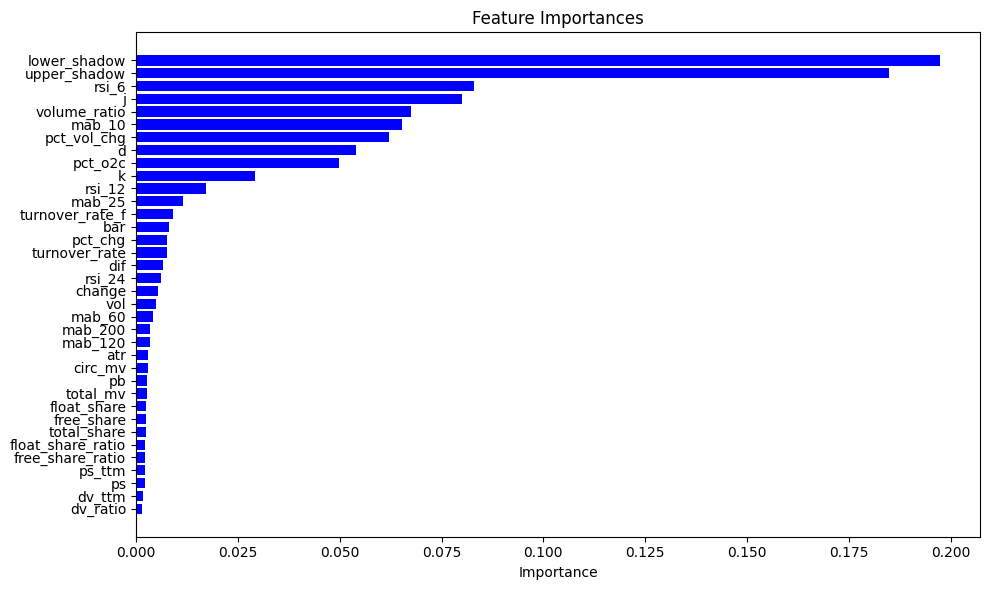

,Feature,Importance
6,lower_shadow,0.197321
7,upper_shadow,0.184840
10,rsi_6,0.082932
15,j,0.080132
18,volume_ratio,0.067501
31,mab_10,0.065380
4,pct_vol_chg,0.062087
14,d,0.054056
5,pct_o2c,0.049903
13,k,0.029217


In [20]:
feature_importance(model, X_train)

In [21]:
print("Fit Report:")
report_metrics_train = print_fit_report(model, X_train, y_train["top_or_bottom_optimized"])

Fit Report:
Recall (weighted): 0.5401
              precision    recall  f1-score   support

           0       0.83      0.44      0.57   5201632
           1       0.38      0.73      0.50   1358594
           2       0.40      0.74      0.52   1363835

    accuracy                           0.54   7924061
   macro avg       0.53      0.64      0.53   7924061
weighted avg       0.68      0.54      0.55   7924061



In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 获取每个类别的数量
COUNT_PER_CLASS = 100000 # 每个类别的样本数量
class_counts = y_test['top_or_bottom_optimized'].value_counts()
print("原始类别分布:")
print(class_counts)

# 确定少数类的数量
minority_class_counts = class_counts.min()


原始类别分布:
top_or_bottom_optimized
0    2366319
1     593505
2     591375
Name: count, dtype: int64


In [128]:
# sampling_strategy = {0: minority_class_counts}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
sampling_strategy = {0: COUNT_PER_CLASS * 3, 1: COUNT_PER_CLASS, 2: COUNT_PER_CLASS}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_test_resampled, y_test_resampled = rus.fit_resample(X_test, y_test["top_or_bottom_optimized"])
y_test_resampled.value_counts()

top_or_bottom_optimized
0    300000
1    100000
2    100000
Name: count, dtype: int64

In [129]:
X_test_resampled = X_test_resampled[features]

In [22]:
print("Model Evaluation Report:")
report_metrics_test = print_fit_report(model, X_test, y_test["top_or_bottom_optimized"])
print("Model evaluation complete.")

Model Evaluation Report:
Recall (weighted): 0.5379
              precision    recall  f1-score   support

           0       0.81      0.46      0.59   2351820
           1       0.36      0.65      0.47    589474
           2       0.38      0.73      0.50    587278

    accuracy                           0.54   3528572
   macro avg       0.52      0.61      0.52   3528572
weighted avg       0.66      0.54      0.55   3528572

Model evaluation complete.


In [ ]:
save_training_results(model_name, params, report_metrics_train, report_metrics_test, freq=FREQ, version=VERSION, label_values=y_test["top_or_bottom_optimized"].value_counts())

Results saved to training_results.csv


In [ ]:
print("Start Drawing Learning Curve")
draw_learning_curve(model, X_train, y_train, cv=5, scoring=None, title="Learning Curve")

In [ ]:
# 保存模型
save_model(model, MODEL_NAME, freq=FREQ, pred_type="STDOPT")
print("Model saved.")

dataset内容分析和重新采样

处理周线/月线训练集重新采样